# Fraud Loss Forecasting Demo (Q1 2026)

This notebook demonstrates how to build and compare fraud loss forecasting approaches on synthetic Q1 2026 data.

**Techniques covered**
- Naive baselines
- Moving average forecasting
- Exponential smoothing
- SARIMAX with exogenous drivers
- Ridge regression
- Random forest
- Gradient boosting

The data is generated synthetically so the notebook can be run end to end without any external dependencies.

## 1) Load or generate the synthetic dataset

If the CSV is missing, the notebook will call the companion generator script and create it automatically.

In [1]:

from pathlib import Path
import subprocess
import sys
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

DATA_PATH = Path("q1_2026_synthetic_fraud_losses.csv")
GENERATOR_PATH = Path("fraud_loss_data_generator.py")

if not DATA_PATH.exists():
    if not GENERATOR_PATH.exists():
        raise FileNotFoundError("Missing both the CSV and the generator script.")
    subprocess.run([sys.executable, str(GENERATOR_PATH), "--output", str(DATA_PATH)], check=True)

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["txn_value_dollars"] = df["transaction_count"] * df["avg_txn_value"]

print(f"Loaded {len(df):,} rows spanning {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Loaded 6,480 rows spanning 2026-01-01 to 2026-03-31


,date,month,day,day_of_week,week_of_year,weekend_flag,month_end_flag,payday_flag,holiday_flag,product,channel,region,customer_segment,device_type,promo_exposure_flag,campaign_flag,control_change_flag,transaction_count,avg_txn_value,active_customers,new_accounts,login_failures,otp_failures,chargeback_count,fraud_alerts,manual_review_rate,approval_rate,decline_rate,device_risk_score,fraud_rate,fraud_cases,fraud_loss,txn_value_dollars
0,2026-01-01,1,1,3,1,0,0,1,1,credit_card,branch,east,premium,desktop,0,0,0,483,50.97,230,12,4,6,2,3,0.0211,0.8616,0.1384,0.2733,0.000328,1,77.47,24618.51
1,2026-01-01,1,1,3,1,0,0,1,1,credit_card,branch,east,retail,desktop,0,0,0,766,68.13,374,33,12,8,3,6,0.0245,0.8575,0.1425,0.2191,0.000485,1,0.00,52187.58
2,2026-01-01,1,1,3,1,0,0,1,1,credit_card,branch,north,premium,desktop,0,0,0,592,38.85,193,14,14,5,1,6,0.0208,0.8455,0.1545,0.2901,0.000345,1,0.00,22999.20
3,2026-01-01,1,1,3,1,0,0,1,1,credit_card,branch,north,retail,desktop,0,0,0,851,41.43,381,22,6,7,1,4,0.0137,0.8664,0.1336,0.2338,0.000481,0,0.00,35256.93
4,2026-01-01,1,1,3,1,0,0,1,1,credit_card,branch,south,premium,desktop,0,0,0,493,70.90,191,18,10,6,3,4,0.0165,0.8618,0.1382,0.2864,0.000379,1,126.83,34953.70


## 2) Create a daily forecast table

The raw file is a panel dataset by date, product, channel, region, customer segment, and device type.  
For forecasting, we aggregate to daily totals and add calendar and mix features.

In [2]:

daily = df.groupby("date").agg(
    fraud_loss=("fraud_loss", "sum"),
    fraud_cases=("fraud_cases", "sum"),
    transaction_count=("transaction_count", "sum"),
    txn_value_dollars=("txn_value_dollars", "sum"),
    active_customers=("active_customers", "sum"),
    new_accounts=("new_accounts", "sum"),
    login_failures=("login_failures", "sum"),
    otp_failures=("otp_failures", "sum"),
    chargeback_count=("chargeback_count", "sum"),
    fraud_alerts=("fraud_alerts", "sum"),
    manual_review_rate=("manual_review_rate", "mean"),
    approval_rate=("approval_rate", "mean"),
    decline_rate=("decline_rate", "mean"),
    device_risk_score=("device_risk_score", "mean"),
    promo_exposure_flag=("promo_exposure_flag", "sum"),
    campaign_flag=("campaign_flag", "sum"),
    control_change_flag=("control_change_flag", "sum"),
    weekend_flag=("weekend_flag", "max"),
    holiday_flag=("holiday_flag", "max"),
    payday_flag=("payday_flag", "max"),
    month_end_flag=("month_end_flag", "max"),
).reset_index()

daily["avg_txn_value"] = daily["txn_value_dollars"] / daily["transaction_count"]
daily["fraud_loss_per_1k_txn"] = 1000 * daily["fraud_loss"] / daily["transaction_count"]
daily["fraud_cases_per_1k_txn"] = 1000 * daily["fraud_cases"] / daily["transaction_count"]

for cat in ["product", "channel", "region", "customer_segment"]:
    piv = pd.pivot_table(
        df,
        index="date",
        columns=cat,
        values="transaction_count",
        aggfunc="sum",
        fill_value=0,
    )
    piv = piv.div(piv.sum(axis=1), axis=0)
    piv.columns = [f"{cat}_{c}_share" for c in piv.columns]
    daily = daily.merge(piv.reset_index(), on="date", how="left")

daily["day_of_week"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["day_of_month"] = daily["date"].dt.day
daily["week_of_year"] = daily["date"].dt.isocalendar().week.astype(int)
daily["sin_doy"] = np.sin(2 * np.pi * daily["date"].dt.dayofyear / 365.25)
daily["cos_doy"] = np.cos(2 * np.pi * daily["date"].dt.dayofyear / 365.25)
daily["is_weekend"] = daily["day_of_week"].isin([5, 6]).astype(int)

daily = daily.sort_values("date").reset_index(drop=True)

daily.head()


,date,fraud_loss,fraud_cases,transaction_count,txn_value_dollars,active_customers,new_accounts,login_failures,otp_failures,chargeback_count,fraud_alerts,manual_review_rate,approval_rate,decline_rate,device_risk_score,promo_exposure_flag,campaign_flag,control_change_flag,weekend_flag,holiday_flag,payday_flag,month_end_flag,avg_txn_value,fraud_loss_per_1k_txn,fraud_cases_per_1k_txn,product_credit_card_share,product_debit_card_share,product_digital_wallet_share,channel_branch_share,channel_mobile_app_share,channel_web_share,region_east_share,region_north_share,region_south_share,region_west_share,customer_segment_premium_share,customer_segment_retail_share,day_of_week,month,day_of_month,week_of_year,sin_doy,cos_doy,is_weekend
0,2026-01-01,8064.14,91,108931,7081221.79,44138,1292,1101,552,128,678,0.020203,0.858097,0.141903,0.326949,0,0,0,0,1,1,0,65.006488,74.029799,0.835391,0.405238,0.329199,0.265563,0.124941,0.517015,0.358043,0.260266,0.237527,0.230338,0.271869,0.416998,0.583002,3,1,1,1,0.017202,0.999852,0
1,2026-01-02,8178.90,77,127037,8671702.08,53313,1237,1013,488,149,622,0.020461,0.859881,0.140119,0.344035,0,0,0,0,0,0,0,68.261232,64.382030,0.606123,0.411242,0.312704,0.276053,0.119170,0.513260,0.367570,0.247125,0.254052,0.240631,0.258192,0.398498,0.601502,4,1,2,1,0.034398,0.999408,0
2,2026-01-03,7399.12,77,108391,7800283.84,48280,1297,1198,517,140,699,0.020069,0.850446,0.149554,0.331921,0,0,0,1,0,0,0,71.964313,68.263232,0.710391,0.397671,0.341975,0.260354,0.125103,0.505817,0.369080,0.242742,0.255169,0.229143,0.272947,0.400596,0.599404,5,1,3,1,0.051584,0.998669,1
3,2026-01-04,6332.26,70,112225,7371611.70,46612,1266,1211,549,155,653,0.019965,0.850562,0.149438,0.330315,0,0,0,1,0,0,0,65.686003,56.424683,0.623747,0.392987,0.328349,0.278663,0.121283,0.536592,0.342125,0.243769,0.266171,0.224041,0.266019,0.404179,0.595821,6,1,4,1,0.068755,0.997634,1
4,2026-01-05,6412.75,72,124210,9369023.45,53384,1278,1059,530,132,633,0.019908,0.858274,0.141726,0.325751,0,0,0,0,0,0,0,75.428898,51.628291,0.579663,0.389558,0.330312,0.280130,0.123589,0.532051,0.344360,0.243861,0.265019,0.228460,0.262660,0.417543,0.582457,0,1,5,2,0.085906,0.996303,0


In [3]:
daily[["fraud_loss", "transaction_count", "fraud_cases", "login_failures", "chargeback_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
fraud_loss,90.0,7284.339556,1229.506948,4455.89,6413.855,7311.485,8146.095,9907.02
transaction_count,90.0,126601.000000,13248.963528,94998.00,119043.000,127605.000,134576.250,170423.00
fraud_cases,90.0,83.700000,12.502988,58.00,77.000,83.000,93.000,118.00
login_failures,90.0,1135.500000,71.490433,1001.00,1081.000,1128.000,1180.500,1310.00
chargeback_count,90.0,151.800000,17.356927,119.00,139.250,149.500,161.750,194.00


## 3) Quick exploratory view

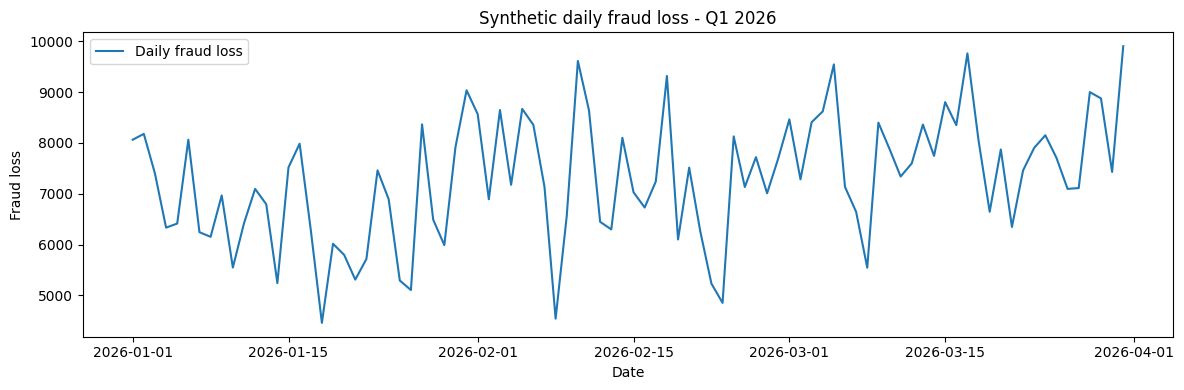

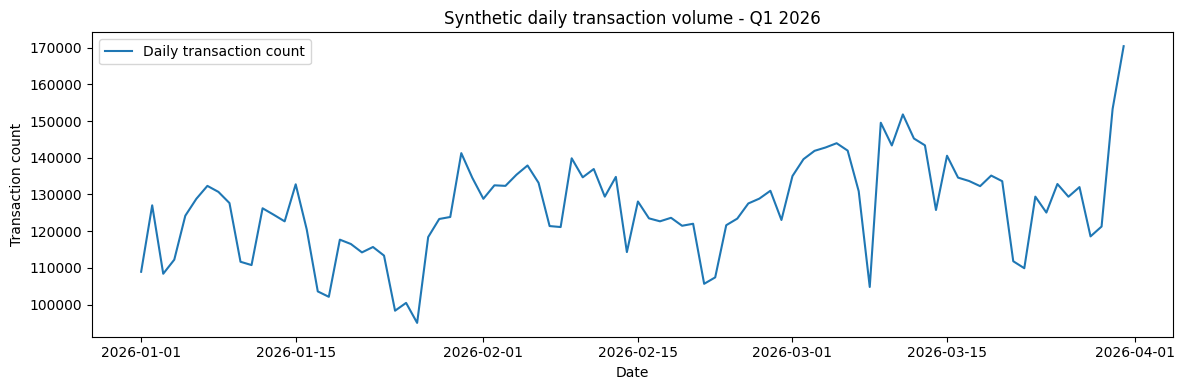

In [4]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["date"], daily["fraud_loss"], label="Daily fraud loss")
ax.set_title("Synthetic daily fraud loss - Q1 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Fraud loss")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["date"], daily["transaction_count"], label="Daily transaction count")
ax.set_title("Synthetic daily transaction volume - Q1 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Transaction count")
ax.legend()
plt.tight_layout()
plt.show()


### 📊 Visualization Summary
- **Fraud Loss (Top Graph)**: Daily fraud losses in Q1 2026 fluctuate between ~4,000 and 10,000, showing sharp spikes and dips.  
- **Transaction Volume (Bottom Graph)**: Daily transaction counts range from ~100,000 to 170,000, with noticeable peaks and troughs.  
- **Key Insight**: Fraud losses appear to move in relation to transaction volumes, suggesting transaction activity may be an important driver for fraud risk forecasting.


## 4) Feature engineering for forecasting

We use lagged target features plus exogenous variables that a real risk team would typically monitor.

In [5]:

model_df = daily.copy()

for lag in [1, 7, 14]:
    model_df[f"lag_{lag}"] = model_df["fraud_loss"].shift(lag)

model_df["rolling_mean_7"] = model_df["fraud_loss"].shift(1).rolling(7).mean()
model_df["rolling_std_7"] = model_df["fraud_loss"].shift(1).rolling(7).std()
model_df["ewm_7"] = model_df["fraud_loss"].shift(1).ewm(span=7, adjust=False).mean()

feature_cols = [
    "transaction_count",
    "avg_txn_value",
    "login_failures",
    "otp_failures",
    "chargeback_count",
    "new_accounts",
    "fraud_alerts",
    "manual_review_rate",
    "approval_rate",
    "decline_rate",
    "device_risk_score",
    "promo_exposure_flag",
    "campaign_flag",
    "control_change_flag",
    "weekend_flag",
    "holiday_flag",
    "payday_flag",
    "month_end_flag",
    "product_credit_card_share",
    "product_debit_card_share",
    "product_digital_wallet_share",
    "channel_mobile_app_share",
    "channel_web_share",
    "channel_branch_share",
    "customer_segment_retail_share",
    "customer_segment_premium_share",
    "day_of_week",
    "month",
    "day_of_month",
    "week_of_year",
    "sin_doy",
    "cos_doy",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "ewm_7",
]

model_df = model_df.dropna().reset_index(drop=True)
print("Modeling rows:", len(model_df))
model_df.head()


Modeling rows: 76


,date,fraud_loss,fraud_cases,transaction_count,txn_value_dollars,active_customers,new_accounts,login_failures,otp_failures,chargeback_count,fraud_alerts,manual_review_rate,approval_rate,decline_rate,device_risk_score,promo_exposure_flag,campaign_flag,control_change_flag,weekend_flag,holiday_flag,payday_flag,month_end_flag,avg_txn_value,fraud_loss_per_1k_txn,fraud_cases_per_1k_txn,product_credit_card_share,product_debit_card_share,product_digital_wallet_share,channel_branch_share,channel_mobile_app_share,channel_web_share,region_east_share,region_north_share,region_south_share,region_west_share,customer_segment_premium_share,customer_segment_retail_share,day_of_week,month,day_of_month,week_of_year,sin_doy,cos_doy,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,ewm_7
0,2026-01-15,7519.52,83,132770,9453629.31,57715,1259,1108,527,138,657,0.020062,0.858571,0.141429,0.317811,0,0,0,0,0,1,0,71.203053,56.635686,0.625141,0.397914,0.331897,0.270189,0.126489,0.535287,0.338224,0.241892,0.236770,0.248912,0.272426,0.407268,0.592732,3,1,15,3,0.255182,0.966893,0,5239.36,6150.99,8064.14,6315.511429,712.792692,6338.045722
1,2026-01-16,7985.71,89,120453,8672474.85,53179,1250,1063,549,179,650,0.019736,0.861938,0.138063,0.331369,0,0,0,0,0,0,0,71.998828,66.297311,0.738877,0.403377,0.315401,0.281222,0.118835,0.516666,0.364499,0.253867,0.255419,0.227873,0.262841,0.390833,0.609167,4,1,16,3,0.271777,0.962360,0,7519.52,6966.46,8178.90,6511.015714,837.004220,6633.414292
2,2026-01-17,6290.53,69,103579,7522187.37,42507,1295,1258,522,136,713,0.018918,0.852367,0.147633,0.327826,0,0,0,1,0,0,0,72.622707,60.731712,0.666158,0.381313,0.347860,0.270827,0.118335,0.525087,0.356578,0.238398,0.239054,0.249539,0.273009,0.403393,0.596607,5,1,17,3,0.288291,0.957543,1,7985.71,5545.67,7399.12,6656.622857,1001.859941,6971.488219
3,2026-01-18,4455.89,58,102101,6764592.81,45777,1257,1196,520,123,656,0.019911,0.851346,0.148654,0.332794,0,0,0,1,0,0,0,66.253933,43.641982,0.568065,0.411171,0.319811,0.269018,0.127011,0.528692,0.344296,0.239929,0.251516,0.238529,0.270027,0.403640,0.596360,6,1,18,3,0.304719,0.952442,1,6290.53,6417.17,6332.26,6763.031429,898.414185,6801.248664
4,2026-01-19,6014.49,70,117682,7835492.80,52671,1244,1094,548,139,659,0.019669,0.858964,0.141036,0.334025,0,0,0,0,0,0,0,66.581914,51.107986,0.594823,0.396195,0.329566,0.274239,0.116347,0.512610,0.371042,0.248092,0.254499,0.229406,0.268002,0.388335,0.611665,0,1,19,4,0.321058,0.947060,0,4455.89,7095.10,6412.75,6482.848571,1258.084039,6214.908998


**Output interpretation**

The displayed `model_df.head()` now includes forecast-ready features. Lag features like `lag_1`, `lag_7`, and `lag_14` give the model recent fraud-loss history. Rolling features summarize recent behavior without using the current day's target.

Rows with missing lag values are dropped, so the modeling dataset starts later than the raw dataset. This is expected because the first days do not have enough prior history to calculate all lag and rolling features.


## 5) Train/test split

We keep the last 14 days as a holdout period for backtesting.

In [6]:

horizon = 14
cutoff_date = model_df["date"].iloc[-horizon]

train = model_df[model_df["date"] < cutoff_date].copy()
test = model_df[model_df["date"] >= cutoff_date].copy()

y_train = train["fraud_loss"]
y_test = test["fraud_loss"]

print("Train period:", train["date"].min().date(), "to", train["date"].max().date(), "rows:", len(train))
print("Test period :", test["date"].min().date(), "to", test["date"].max().date(), "rows:", len(test))


Train period: 2026-01-15 to 2026-03-17 rows: 62
Test period : 2026-03-18 to 2026-03-31 rows: 14


**Output interpretation**

The printed train and test periods confirm that this is a time-based split. Earlier dates are used for training, and the most recent 14 days are held out for evaluation.

This avoids future-data leakage. In forecasting, we should not randomly split rows because that can train the model on future dates and test it on earlier dates, producing overly optimistic accuracy.


## 6) Baseline, statistical, and ML forecasts

The comparison includes simple baselines, a classical time-series model, and a few machine learning regressors.

In [7]:

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-6))) * 100

predictions = {}

# 1) Seasonal naive baseline
predictions["Seasonal Naive (7-day)"] = daily["fraud_loss"].shift(7).iloc[-horizon:].values

# 2) 7-day moving average baseline
predictions["7-Day Moving Avg"] = daily["fraud_loss"].shift(1).rolling(7).mean().iloc[-horizon:].values

# 3) Exponential smoothing
es_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
).fit(optimized=True)

predictions["Exponential Smoothing"] = es_model.forecast(horizon).values

# 4) SARIMAX with exogenous drivers
sarimax_exog_cols = [
    "transaction_count",
    "avg_txn_value",
    "login_failures",
    "otp_failures",
    "chargeback_count",
    "new_accounts",
    "fraud_alerts",
    "promo_exposure_flag",
    "campaign_flag",
    "control_change_flag",
    "weekend_flag",
    "holiday_flag",
    "payday_flag",
    "month_end_flag",
]

sarimax = SARIMAX(
    y_train,
    exog=train[sarimax_exog_cols],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

predictions["SARIMAX"] = sarimax.forecast(horizon, exog=test[sarimax_exog_cols]).values

# 5) Machine learning models
X_train = train[feature_cols]
X_test = test[feature_cols]

ml_models = {
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=2.0)),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=250,
        max_depth=3,
    ),
}

for name, model in ml_models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

results = []
for name, pred in predictions.items():
    results.append({
        "model": name,
        "rmse": rmse(y_test, pred),
        "mae": mean_absolute_error(y_test, pred),
        "mape_%": mape(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df


,model,rmse,mae,mape_%
0,SARIMAX,841.152890,683.380812,8.746740
1,Random Forest,954.915904,694.400190,8.566235
2,Gradient Boosting,958.245896,754.464334,9.386943
3,Exponential Smoothing,1025.073717,871.428852,11.704412
4,7-Day Moving Avg,1049.729164,818.037449,10.527403
5,Ridge Regression,1138.539176,950.925604,12.268459
6,Seasonal Naive (7-day),1239.006262,1058.077143,13.282734



### 🔎 Key Insights
- **SARIMAX** achieves the lowest RMSE and MAE, making it the most stable and accurate overall.  
- **Random Forest** has the lowest MAPE, meaning it performs slightly better in terms of relative percentage error.  
- **Gradient Boosting** is close to Random Forest but slightly weaker across all metrics.  
- Simpler statistical baselines (Exponential Smoothing, Moving Average, Seasonal Naive) perform worse, confirming the value of more advanced models.


## 7) Compare forecasts visually

In [8]:

comparison = pd.DataFrame({"date": test["date"].values, "actual": y_test.values})

for name, pred in predictions.items():
    comparison[name] = pred

comparison.head()


,date,actual,Seasonal Naive (7-day),7-Day Moving Avg,Exponential Smoothing,SARIMAX,Ridge Regression,Random Forest,Gradient Boosting
0,2026-03-18,8047.40,7339.02,8280.892857,8333.167958,8462.696145,7886.869148,8110.995194,8196.354534
1,2026-03-19,6645.34,7598.07,8382.090000,8179.059505,5927.455190,5981.122201,7700.792037,7821.097512
2,2026-03-20,7872.44,8363.03,8245.985714,8482.433491,6978.035476,6961.155528,7906.164802,7932.275597
3,2026-03-21,6346.00,7745.57,8175.901429,8233.522341,4946.709638,4820.317423,6047.025585,6365.730375
4,2026-03-22,7459.29,8804.61,7975.962857,7359.221642,6315.089780,5116.436947,6349.763807,5906.538578


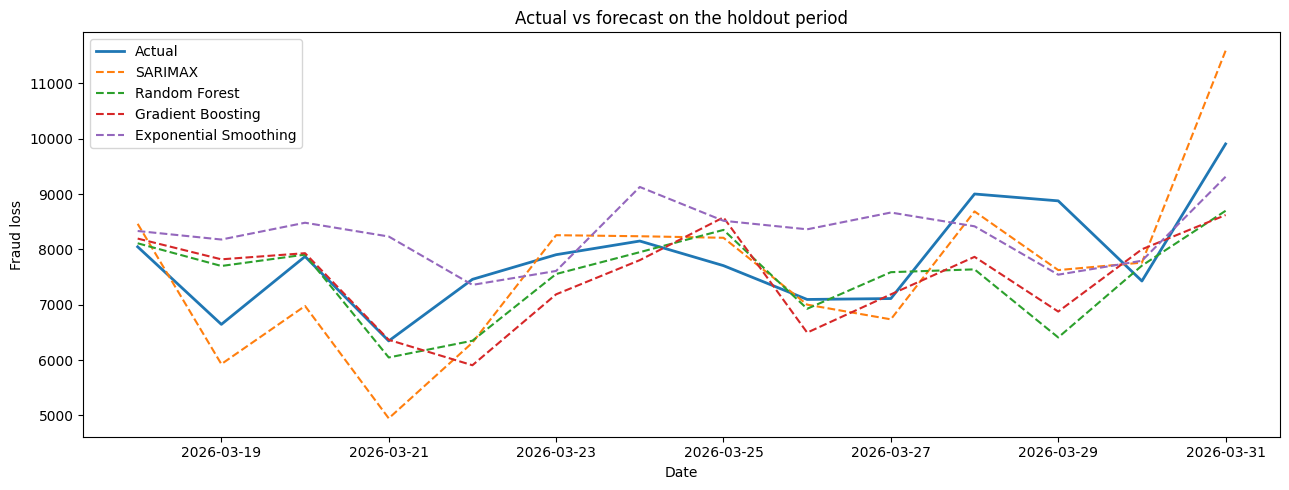

In [9]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(comparison["date"], comparison["actual"], label="Actual", linewidth=2)
for name in ["SARIMAX", "Random Forest", "Gradient Boosting", "Exponential Smoothing"]:
    ax.plot(comparison["date"], comparison[name], label=name, linestyle="--")

ax.set_title("Actual vs forecast on the holdout period")
ax.set_xlabel("Date")
ax.set_ylabel("Fraud loss")
ax.legend()
plt.tight_layout()
plt.show()


## 📊 Actual vs Forecast (Holdout Period)

### 💡 Key Insight
- SARIMAX consistently follows the actual fraud loss curve most closely.  
- Random Forest performs well on percentage accuracy but misses some peaks.  
- Gradient Boosting and Exponential Smoothing show weaker fit, especially during sharp fluctuations.  
- Overall, SARIMAX demonstrates the best stability and alignment in this holdout test.

## 8) Feature importance from the gradient boosting model

This helps show which operational drivers matter most in the synthetic data.

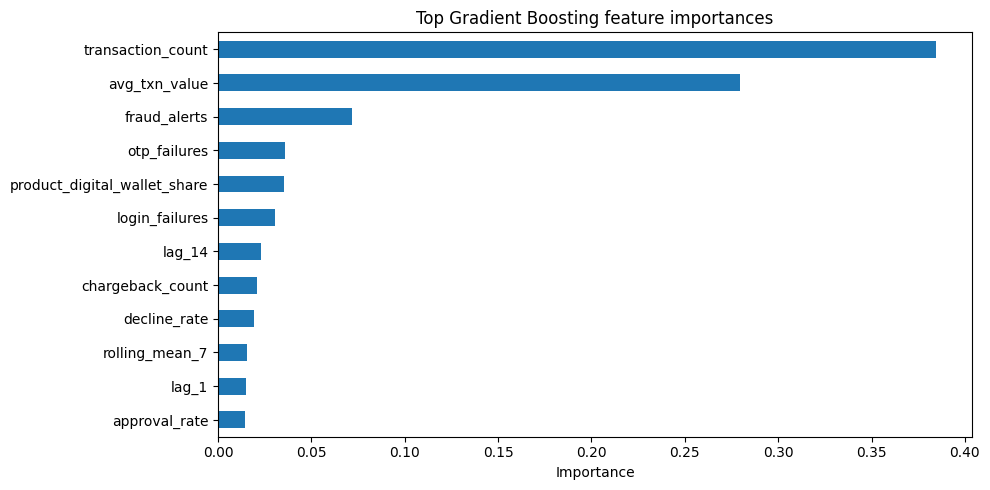

transaction_count               0.384546
avg_txn_value                   0.279557
fraud_alerts                    0.071507
otp_failures                    0.035668
product_digital_wallet_share    0.035300
login_failures                  0.030735
lag_14                          0.023049
chargeback_count                0.020662
decline_rate                    0.019225
rolling_mean_7                  0.015220
lag_1                           0.014705
approval_rate                   0.014339
dtype: float64

In [10]:

gb_model = ml_models["Gradient Boosting"]
importances = pd.Series(gb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_importances = importances.head(12).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
top_importances.plot(kind="barh", ax=ax)
ax.set_title("Top Gradient Boosting feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

top_importances.sort_values(ascending=False)


## 📊 Gradient Boosting Feature Importances

### 💡 Key Insight
- Transaction volume and average transaction value dominate the model’s predictive power.  
- Behavioral and temporal features (alerts, failures, lags) add strong explanatory context.  
- This mix of **volume, value, behavior, and time-based features** shows Gradient Boosting is leveraging diverse signals to forecast fraud losses effectively.

## 9) Final takeaways

- Classical forecasting methods provide a strong benchmark.
- Exogenous business drivers improve forecast quality.
- Feature engineering and lag structure matter a lot for fraud loss prediction.
- For a real banking environment, you would also add governance, backtesting, and model monitoring.